In [1]:
!pip install torch torchviz matplotlib

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# # Download some digit images from the MNIST dataset
# !curl -o "mnist_0.jpg" "https://learnopencv.com/wp-content/uploads/2024/07/mnist_0.jpg"
# !curl -o "mnist_1.jpg" "https://learnopencv.com/wp-content/uploads/2024/07/mnist_1.jpg"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   448  100   448    0     0    680      0 --:--:-- --:--:-- --:--:--   679
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   436  100   436    0     0    738      0 --:--:-- --:--:-- --:--:--   738


In [48]:
import torch
import matplotlib.pyplot as plt
import cv2
import numpy as np


torch.__version__

'2.11.0'

In [49]:
digital_0_array_orig = cv2.imread("mnist_0.jpg")
digital_1_array_orig = cv2.imread("mnist_1.jpg")

digital_0_array_gray = cv2.imread("mnist_0.jpg", cv2.IMREAD_GRAYSCALE)
digital_1_array_gray = cv2.imread("mnist_1.jpg", cv2.IMREAD_GRAYSCALE)

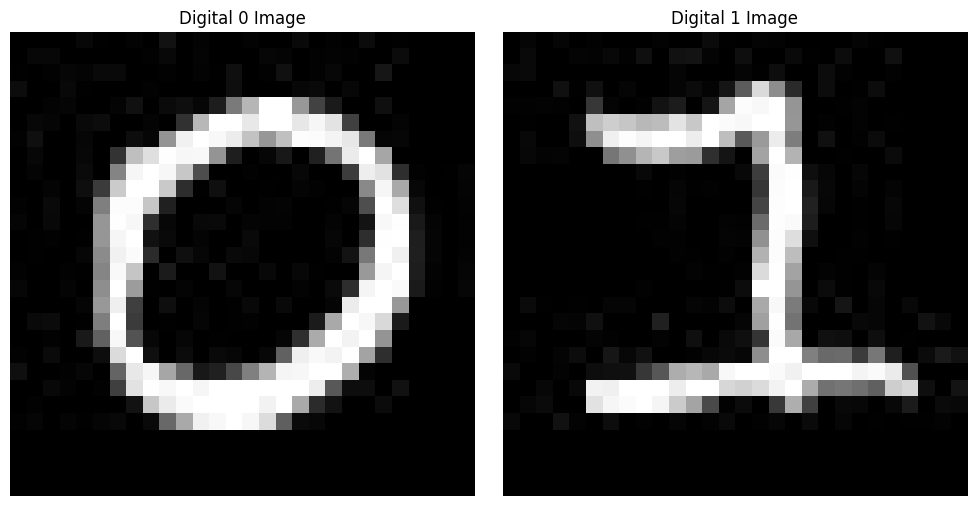

In [52]:
# visualize image in matplotlib
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(digital_0_array_orig, cmap="gray", interpolation="none")
axes[0].set_title("Digital 0 Image")
axes[0].axis("off")

axes[1].imshow(digital_1_array_orig, cmap="gray", interpolation="none")
axes[1].set_title("Digital 1 Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [53]:
# size of image
digital_1_array_orig.shape, np.min(digital_1_array_orig), np.max(digital_1_array_orig)

((28, 28, 3), np.uint8(0), np.uint8(255))

In [69]:
digital_1_array_gray.shape

(28, 28)

In [83]:
# numpy reads as 8 bit
np.max(digital_1_array_gray), digital_1_array_gray[0].dtype

(np.uint8(255), dtype('uint8'))

## Convert NumPy Array To Tensor

In [84]:
# numpy dimention is in 8 bit and we change data type to float32
# normalize by dividing by 255 to get values between 0-1
img_tensor_0 = torch.tensor(digital_0_array_orig, dtype=torch.float32) / 255.0
img_tensor_1 = torch.tensor(digital_1_array_orig, dtype=torch.float32) / 255.0

In [87]:
img_tensor_0.shape, torch.min(img_tensor_0), torch.max(img_tensor_0)

(torch.Size([28, 28, 3]), tensor(0.), tensor(1.))

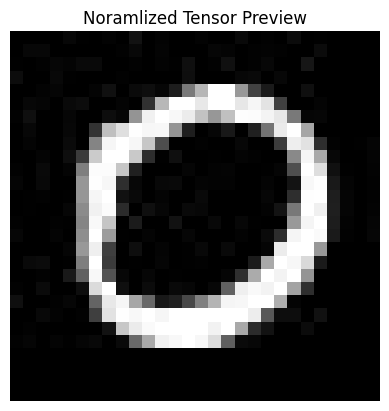

In [89]:
plt.imshow(img_tensor_0, cmap="gray")
plt.title("Noramlized Tensor Preview")
plt.axis("off")
plt.show()

## Create a batch for training input

In [95]:
batch_tensor = torch.stack([img_tensor_0, img_tensor_1])
batch_tensor.shape

torch.Size([2, 28, 28, 3])

In [96]:
batch_tensor = batch_tensor.permute(0, 3, 1, 2)
batch_tensor.shape

torch.Size([2, 3, 28, 28])

## Tensor Creation

In [106]:
torch.ones(5, 2), torch.zeros(5, 5), torch.rand(5)

(tensor([[1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.]]),
 tensor([[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]]),
 tensor([0.1486, 0.1834, 0.1084, 0.3181, 0.8420]))

In [112]:
x = torch.tensor([[1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.]])

x.dtype

torch.float32

In [122]:
x[0, 1], x[0][1], x[:, 1], x[:]

(tensor(1.),
 tensor(1.),
 tensor([1., 1., 1., 1., 1.]),
 tensor([[1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.],
         [1., 1.]]))

## Specify Tensor Data Types

In [129]:
x = torch.tensor([[1, 2, 3], [1, 2, 2]])
y = torch.tensor([[1, 2, 3], [1, 2, 2.]])
x.dtype, y.dtype

(torch.int64, torch.float32)

In [132]:
y.type(torch.int64)

tensor([[1, 2, 3],
        [1, 2, 2]])

## Arithmetic Operations

In [146]:
x = torch.rand([5, 2])
y = torch.rand([5, 2])
x, y

(tensor([[0.0473, 0.7967],
         [0.6084, 0.2498],
         [0.6725, 0.7401],
         [0.4006, 0.2707],
         [0.0256, 0.6588]]),
 tensor([[0.6365, 0.9993],
         [0.0757, 0.0133],
         [0.0065, 0.8730],
         [0.2770, 0.2414],
         [0.1267, 0.7358]]))

In [147]:
x+y

tensor([[0.6838, 1.7961],
        [0.6842, 0.2632],
        [0.6790, 1.6131],
        [0.6776, 0.5121],
        [0.1522, 1.3946]])

In [150]:
# element wise multiplication
x*y

tensor([[0.0301, 0.7962],
        [0.0461, 0.0033],
        [0.0044, 0.6461],
        [0.1110, 0.0653],
        [0.0032, 0.4848]])

In [151]:
# matrix multiplication
torch.mm(x, y.permute(1, 0))

tensor([[0.8263, 0.0142, 0.6959, 0.2054, 0.5922],
        [0.6369, 0.0494, 0.2220, 0.2288, 0.2609],
        [1.1676, 0.0608, 0.6505, 0.3649, 0.6297],
        [0.5255, 0.0340, 0.2389, 0.1763, 0.2499],
        [0.6746, 0.0107, 0.5753, 0.1661, 0.4880]])

In [142]:
x - y

tensor([[-0.2509, -0.5734],
        [-0.1715, -0.2644],
        [-0.3250,  0.3950],
        [-0.2001,  0.3240],
        [ 0.5122,  0.7856]])

## Broadcasting

In [152]:
a = torch.tensor([1, 2, 3])
b = torch.tensor([6])

a+b

tensor([7, 8, 9])

## CPU / GPU

In [156]:
x_cpu = torch.tensor([1, 2, 3], device="cpu")


# x_gpu = torch.tensor([1, 2, 3], device="cuda")

In [159]:
x_cpu * 5


# x_gpu * 5

tensor([ 5, 10, 15])

In [161]:
# x_cpu.to(device="cuda")


# x_gpu.to(device="cpu")